# Figure 2 — Supplementary Material

Supplement items are added incrementally, one at a time. Each section is self-contained and reuses the same `src/` pipeline as `Figure_2_VAR.ipynb`.


In [ ]:
import os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

sys.path.insert(0, str(Path.cwd()))

warnings.filterwarnings("ignore", category=RuntimeWarning)

FIGDIR, RESULTS_DIR = "outputs/figures/var", "outputs/results/var"
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"))
    print(f"saved {FIGDIR}/{name}.{{pdf,png}}")


## S1 — A0 = 0: sign ambiguity and frequency doubling

Removing the stationary VAR component ($A_0=0$) produces a sign ambiguity and frequency doubling in the observable second-order dynamics. When $A_0=0$, the covariance depends on the latent driver through $d_t^2$, such that positive and negative values of $d_t$ produce indistinguishable second-order statistics. For a sinusoidal driver, this quadratic dependence additionally introduces modulation at twice the driver frequency.

In [2]:
from src.sweeps import simulate, evaluate, cfg_with
from src.util import global_zscore, moving_average_centered_any
from src.pearson_edge import build_edges


In [3]:
cfg_d2 = cfg_with(A_0_is_zero=True)
demo_seed = 123

X, d, info = simulate(cfg_d2, seed=demo_seed)
res = evaluate(X, d, cfg_d2, features="edges")

# rebuild the intermediate representations for plotting
Z_s   = moving_average_centered_any(global_zscore(X), cfg_d2["node_win"])
E_raw, pairs = build_edges(Z_s)
E_s   = moving_average_centered_any(E_raw - E_raw.mean(0, keepdims=True), cfg_d2["edge_win"])

print(f"R2 = {res['R2']:.3f}   r = {res['rP']:.3f}   rho_s = {res['rS']:.3f}")
print(f"realised rho(A0) = {info['rho_A0']:.3f}, max_t rho(A_t) = {info['rho_max_realised']:.3f}")


R2 = 0.003   r = 0.054   rho_s = 0.087
realised rho(A0) = 0.000, max_t rho(A_t) = 0.760


saved figures/supp_s1_d2_issue.{pdf,png}


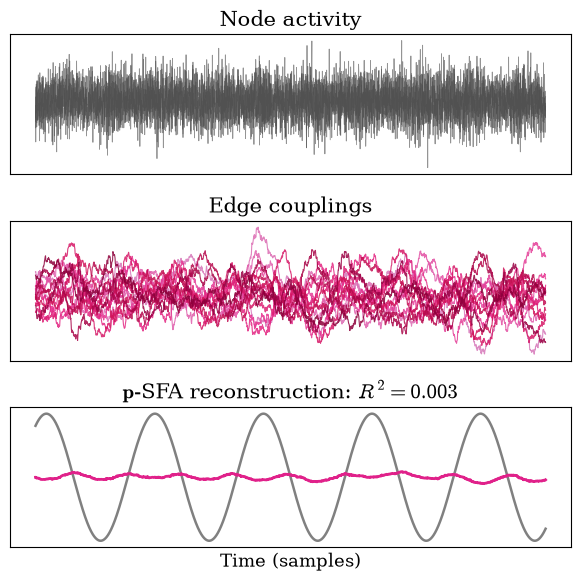

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

COL = {
    "node":   "#4d4d4d",
    "driver": "#111111",
    "edge":   "#E0218A",
}

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=False)

# (i) node activity
t = np.arange(len(Z_s))
for i in range(min(cfg_d2["N"], 4)):
    axes[0].plot(t[::5], Z_s[::5, i], lw=0.6, alpha=0.6, color=COL["node"])

# (ii) edge time series
te = np.arange(len(E_s))
pinks = plt.cm.PuRd(np.linspace(0.45, 0.9, E_s.shape[1]))
for k in range(E_s.shape[1]):
    axes[1].plot(te[::5], E_s[::5, k], lw=0.8, alpha=0.85, color=pinks[k])

# (iii) recovery
td = np.arange(len(res["d_aligned"]))
axes[2].plot(td, res["d_aligned"], color='#808080', lw=1.8)
axes[2].plot(td, res["y_fit"], color=COL["edge"], lw=2.0)

titles = [
    "Node activity",
    "Edge couplings",
    rf"$\bf{{p}}$-SFA reconstruction: $R^2 = {res['R2']:.3f}$",
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

axes[2].set_xlabel("Time (samples)", fontsize=13)

fig.tight_layout(pad=1.4)
save(fig, "supp_s1_d2_issue")


## S2 — Covariance vs. correlation edges across the spectral radius

Comparison of covariance- and correlation-edge p-SFA across the VAR spectral radius. Recovery using covariance edges declines as $\rho_\mathrm{max}$ approaches the stability boundary, whereas correlation-edge recovery remains high. Correlation normalises marginal variance contributions that become increasingly prominent in highly persistent VAR dynamics.

As $\rho_\mathrm{max} \to 1$ the system develops a slow, **shared** amplitude drift that has nothing to do with the driver -- near-unit-root heteroscedasticity in its own dynamics. Covariance edges ($\mathrm{Cov}_{ij}(t)$, unnormalised) inherit that drift directly, giving SFA a spuriously-slow, non-driver direction to latch onto instead. Correlation edges ($\mathrm{Cov}_{ij}(t)/\sqrt{\mathrm{Var}_i(t)\mathrm{Var}_j(t)}$) cancel it algebraically: under a shared multiplicative gain $x_i(t)=g(t)s_i(t)$, the $g(t)^2$ term appears in numerator and denominator alike and drops out exactly.

This is window-size dependent: a longer edge window gives covariance more room to average the drift away within each window, which shrinks the gap. At the canonical `edge_win=601` the effect is real but modest (~0.07 $R^2$ at $\rho_\mathrm{max}=0.99$); at a deliberately shorter window (`edge_win=301`) it's much clearer, so that's what's used below -- the mechanism is the same, just easier to see.

In [5]:
from copy import deepcopy
from src.sweeps import simulate, cfg_with, run_sweep_features, summarise
from src.util import make_driver, moving_average_centered_any
from src.features import build_feature
from src.sfa import affine_align, r2_score
from sksfa import SFA


In [6]:
ACTIVE = cfg_with(target_rho0=0.8, edge_win=601)
SEEDS = range(10)


In [7]:
def null_r2_feature(cfg, name, n_rep=20, seed=1):
    """Driver-free null for a named feature representation: same dynamics
    with a_TVP = 0 (genuinely stationary), scored against the sinusoid that
    would have been the driver.
    """
    null_cfg = deepcopy(cfg)
    null_cfg["tvp_amp"] = 0.0
    null_cfg["tvp_noise_std"] = 0.0
    d_ref = make_driver(cfg["T"], cfg["tvp_amp"], cfg["tvp_period"], phase=cfg["tvp_phase_rad"])
    d_ref = moving_average_centered_any(moving_average_centered_any(d_ref, cfg["node_win"]), cfg["edge_win"])
    out = np.empty(n_rep)
    for k in range(n_rep):
        Xk, _, _ = simulate(null_cfg, seed=seed * 1000 + k)
        Xn = moving_average_centered_any(Xk, cfg["node_win"])
        F = build_feature(name, Xn, cfg["edge_win"])
        m = min(len(d_ref), F.shape[0])
        y = SFA(n_components=1, fill_mode="zero").fit_transform(F[:m])[:, 0]
        y_fit, _, _ = affine_align(y, d_ref[:m])
        out[k] = r2_score(d_ref[:m], y_fit)
    return out


In [8]:
# Deliberately shorter than ACTIVE's canonical edge_win: the corr-vs-cov gap
# is window-size dependent (see markdown above), so this window is chosen to
# make the mechanism visible, not to reflect the canonical operating point.
RHO_DEMO_EDGE_WIN = 301
rho_demo_base = deepcopy(ACTIVE)
rho_demo_base["edge_win"] = RHO_DEMO_EDGE_WIN

rho_vals = np.linspace(0.01, 0.99, num=30)
df_rho_feat = run_sweep_features("rho_max", rho_vals, seeds=SEEDS, base=rho_demo_base,
                                 names=["edges-corr", "edges-cov-win"])

null_rows_corr, null_rows_cov = [], []
for rm in rho_vals:
    cfg_rm = deepcopy(rho_demo_base)
    cfg_rm["rho_max"] = rm
    null_rows_corr.append(dict(rho_max=rm, null_p95=np.percentile(
        null_r2_feature(cfg_rm, "edges-corr", n_rep=20, seed=1), 95)))
    null_rows_cov.append(dict(rho_max=rm, null_p95=np.percentile(
        null_r2_feature(cfg_rm, "edges-cov-win", n_rep=20, seed=2), 95)))

df_null_rho_demo = pd.DataFrame(null_rows_corr)
df_null_rho_cov  = pd.DataFrame(null_rows_cov)


[sweep] rho_max = 0.01   best: edges-corr = 0.024


[sweep] rho_max = 0.04379310344827586   best: edges-corr = 0.023


[sweep] rho_max = 0.07758620689655171   best: edges-cov-win = 0.023


[sweep] rho_max = 0.11137931034482758   best: edges-cov-win = 0.024


[sweep] rho_max = 0.14517241379310344   best: edges-cov-win = 0.026


...

[sweep] rho_max = 0.8548275862068965   best: edges-corr = 0.839


[sweep] rho_max = 0.8886206896551724   best: edges-corr = 0.841


[sweep] rho_max = 0.9224137931034482   best: edges-corr = 0.839


[sweep] rho_max = 0.9562068965517241   best: edges-corr = 0.833


[sweep] rho_max = 0.99   best: edges-corr = 0.823


saved figures/supp_s2_rho_corr_vs_cov.{pdf,png}


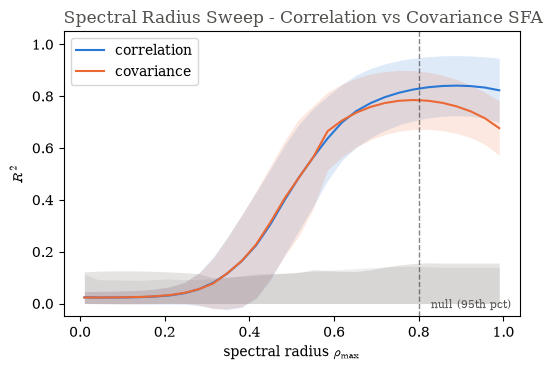

In [9]:
INK    = "#0b0b0b"
MUTED  = "#52514e"
ACCENT = "#2a78d6"   # correlation — the robust representation
NOISE  = "#898781"   # null-band color
COV    = "#eb6834"   # covariance — the less-robust representation

fig, ax = plt.subplots(figsize=(5.4, 3.8))

s_corr = summarise(df_rho_feat, "rho_max", "R2_edges-corr")
s_cov  = summarise(df_rho_feat, "rho_max", "R2_edges-cov-win")

ax.fill_between(df_null_rho_demo["rho_max"], 0, df_null_rho_demo["null_p95"], color=NOISE, alpha=0.22, lw=0)
ax.fill_between(df_null_rho_cov["rho_max"], 0, df_null_rho_cov["null_p95"], color=NOISE, alpha=0.14, lw=0)
ax.text(0.98, 0.02, "null (95th pct)", ha="right", va="bottom",
        fontsize=8, color=MUTED, transform=ax.transAxes)

ax.plot(s_corr["rho_max"], s_corr["mean"], ms=3.5, color=ACCENT, label="correlation")
ax.fill_between(s_corr["rho_max"], s_corr["mean"] - s_corr["sd"], s_corr["mean"] + s_corr["sd"],
                color=ACCENT, alpha=0.15, lw=0)

ax.plot(s_cov["rho_max"], s_cov["mean"], ms=3.5, color=COV, label="covariance")
ax.fill_between(s_cov["rho_max"], s_cov["mean"] - s_cov["sd"], s_cov["mean"] + s_cov["sd"],
                color=COV, alpha=0.15, lw=0)

ax.axvline(ACTIVE["rho_max"], color=INK, ls="--", lw=1.0, alpha=0.5)
ax.set_xlabel(r"spectral radius $\rho_\mathrm{max}$")
ax.set_ylabel(r"$R^2$")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Spectral Radius Sweep - Correlation vs Covariance SFA", loc="left", color=MUTED)
ax.legend(loc="upper left")

fig.tight_layout()
save(fig, "supp_s2_rho_corr_vs_cov")


## S3 — Invariance of p-SFA to isotropic and anisotropic instantaneous Gaussian noise

p-SFA's reconstruction should be robust to the scale of per-timestep observation noise on the underlying VAR process, whether that noise variance is shared equally across all channels (isotropic) or varies by channel (anisotropic): the windowed edge features average out i.i.d. instantaneous noise regardless of its per-channel scale, so recovery is expected to stay high across a wide range of noise levels for both noise structures.

Isotropic noise is already natively supported by `src.VAR.simulate_var_based_on_C` (its `Sigma` parameter *is* the isotropic noise variance). Anisotropic (per-channel) noise has no equivalent in the shared simulator -- that capability only existed in the now-removed `simulate_var_based_on_C_noise`/`_noise2` functions. Rather than reviving those (600+ lines, 7 of 8 noise types unused), the anisotropic case is implemented as a small, notebook-local variant below, reusing every existing building block (`build_C_manual`, `scale_to_spectral_radius`, `spectral_radius`, `make_driver`) and duplicating only the final recursion loop with a per-channel noise covariance.

In [10]:
from src.VAR import simulate_var_based_on_C, build_C_manual
from src.util import set_seed, make_driver, scale_to_spectral_radius, spectral_radius
from src.edge_pipeline import run_sfa_pipeline_windowed


In [11]:
def simulate_var_anisotropic_noise(N, T, sigmas, tvp_amp, tvp_period, seed,
                                   target_rho0, alpha, rho_max, tvp_phase_rad,
                                   A_0_is_zero, C_base, safety_margin=0.95):
    """Same A(t) = A0 + d(t)*C recursion as src.VAR.simulate_var_based_on_C,
    but with per-channel (anisotropic) instantaneous noise instead of a
    single scalar Sigma. Notebook-local by design -- kept out of src/VAR.py
    so the shared simulator stays untouched (see S3 markdown above).

    `sigmas` is a length-N array of per-channel noise variances.
    """
    set_seed(seed)
    d = make_driver(T, tvp_amp, tvp_period, phase=tvp_phase_rad)

    if A_0_is_zero:
        A0 = np.zeros((N, N))
    else:
        A0_raw = np.random.normal(0.0, 1.0, size=(N, N))
        A0 = scale_to_spectral_radius(A0_raw, target_rho0)

    C = alpha * C_base
    if tvp_amp > 0:
        rho_worst = max(spectral_radius(A0 + tvp_amp * C), spectral_radius(A0 - tvp_amp * C))
    else:
        rho_worst = spectral_radius(A0)
    s = min(1.0, (rho_max * safety_margin) / rho_worst) if rho_worst > 0 else 1.0
    A0 = A0 * s
    C = C * s

    L_eta = np.diag(np.sqrt(np.asarray(sigmas, dtype=float)))

    X = np.zeros((T, N))
    x_prev = np.zeros(N)
    for t in range(T):
        At = A0 + d[t] * C
        eta_t = L_eta @ np.random.normal(size=N)
        x_t = At @ x_prev + eta_t
        X[t] = x_t
        x_prev = x_t

    return X, d


In [12]:
N, T = 6, 8000
C_base = build_C_manual(N, entry_dist="uniform", symmetric=True)
sigmas = np.linspace(0.01, 1, 100)

common = dict(tvp_amp=1.0, tvp_period=2000, seed=42, target_rho0=0.8,
             alpha=0.5, rho_max=0.95, tvp_phase_rad=0.0, A_0_is_zero=False,
             C_base=C_base)

R2_isotropic = []
for s in sigmas:
    X, d, *_ = simulate_var_based_on_C(N=N, T=T, Sigma=s, **common)
    res = run_sfa_pipeline_windowed(X, d, features="edges", windowing_mode="rolling",
                                    edge_win=301, node_win=2, plots=False)
    R2_isotropic.append(res["R2"])

R2_anisotropic = []
for s in sigmas:
    channel_sigmas = np.linspace(s * 0.2, s * 2.0, N)
    X, d = simulate_var_anisotropic_noise(N=N, T=T, sigmas=channel_sigmas, **common)
    res = run_sfa_pipeline_windowed(X, d, features="edges", windowing_mode="rolling",
                                    edge_win=301, node_win=2, plots=False)
    R2_anisotropic.append(res["R2"])


saved figures/supp_s3_noise_invariance.{pdf,png}


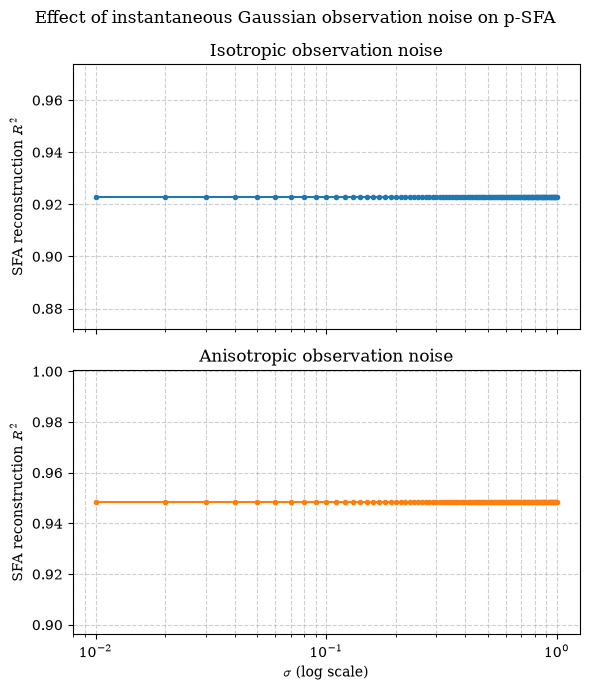

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

axes[0].semilogx(sigmas, R2_isotropic, "-o", ms=3, color="tab:blue")
axes[0].set_ylabel(r"SFA reconstruction $R^2$")
axes[0].set_title("Isotropic observation noise")
axes[0].grid(True, which="both", ls="--", alpha=0.6)

axes[1].semilogx(sigmas, R2_anisotropic, "-o", ms=3, color="tab:orange")
axes[1].set_xlabel(r"$\sigma$ (log scale)")
axes[1].set_ylabel(r"SFA reconstruction $R^2$")
axes[1].set_title("Anisotropic observation noise")
axes[1].grid(True, which="both", ls="--", alpha=0.6)

fig.suptitle("Effect of instantaneous Gaussian observation noise on p-SFA")
fig.tight_layout()
save(fig, "supp_s3_noise_invariance")


## S4 — Two competing drivers in the construction of the TVP VAR

When two latent drivers of different timescales jointly modulate the coupling structure ($A(t) = A_0 + d_1(t)C_1 + d_2(t)C_2$), p-SFA's two slowest components recover each driver separately -- provided they are at different timescales, p-SFA can uncover them both. The slowness (delta-value) spectrum should show a clear gap between these two meaningful components and the noise floor of the remaining components.

Ported from `/Users/ritviksharma/Projects/DNS-research/extended_VAR_results.ipynb`. Nothing in `src/VAR.py` supports two simultaneous driver channels, so the generator and the multi-driver pipeline wrapper are notebook-local (same precedent as S3's anisotropic-noise variant) -- but every piece that already exists (`make_driver`, `spectral_radius`, `scale_to_spectral_radius`, `build_edges`, `moving_average_centered_any`, `global_zscore`, `pearson_r`) is reused rather than redefined.

In [14]:
from src.util import (make_driver, spectral_radius, scale_to_spectral_radius,
                      global_zscore, moving_average_centered_any)
from src.pearson_edge import build_edges
from src.sfa import pearson_r
from sksfa import SFA


In [15]:
def simulate_var_two_drivers(N=10, T=8000, Sigma=0.03,
                             rho_max=0.8, target_rho0=0.8,
                             alpha1=0.9, alpha2=0.9,
                             period1=620, period2=175, phase2=np.pi / 3, seed=1):
    """VAR(1) jointly modulated by two independent sinusoidal drivers at
    different timescales: A(t) = A0 + d1(t)*C1 + d2(t)*C2.
    """
    np.random.seed(seed)
    d1 = make_driver(T, amp=1.0, period=period1, phase=0.0)
    d2 = make_driver(T, amp=0.8, period=period2, phase=phase2)

    A0_raw = np.random.normal(0, 1, (N, N))
    A0 = scale_to_spectral_radius(A0_raw, target_rho0)

    C1 = np.random.normal(0, 1, (N, N)); C1 = 0.5 * (C1 + C1.T)
    C2 = np.random.normal(0, 1, (N, N)); C2 = 0.5 * (C2 + C2.T)
    C1 = C1 * alpha1
    C2 = C2 * alpha2

    # Stability: sample rho(A(t)) across the trajectory -- with two
    # independent periods the combined worst-case instant has no closed form.
    rho_test = []
    for tt in np.linspace(0, T - 1, 500, dtype=int):
        At = A0 + d1[tt] * C1 + d2[tt] * C2
        rho_test.append(spectral_radius(At))
    s = min(1.0, (rho_max * 0.95) / max(rho_test))
    A0 = A0 * s
    C1 = C1 * s
    C2 = C2 * s

    X = np.zeros((T, N))
    x_prev = np.zeros(N)
    for t in range(T):
        At = A0 + d1[t] * C1 + d2[t] * C2
        eps = np.sqrt(Sigma) * np.random.randn(N)
        x_t = At @ x_prev + eps
        X[t] = x_t
        x_prev = x_t

    return X, d1, d2


def run_sfa_pipeline_windowed_multi(X, D, edge_win=50, node_win=2, n_components=5):
    """Multi-driver variant of run_sfa_pipeline_windowed: D has one column
    per latent driver, and every SFA component is kept (not just the
    slowest), so each recovered component can be matched to its driver.
    """
    T, N = X.shape
    if D.ndim == 1:
        D = D[:, None]
    K = D.shape[1]

    if node_win > 1:
        Xn = moving_average_centered_any(X, node_win)
        Dn = np.column_stack([moving_average_centered_any(D[:, k], node_win) for k in range(K)])
    else:
        Xn, Dn = X.copy(), D.copy()

    Z = global_zscore(Xn)
    E_raw, _ = build_edges(Z)
    F = E_raw - E_raw.mean(axis=0, keepdims=True)

    if edge_win > 1:
        F = moving_average_centered_any(F, edge_win)
        Dn = np.column_stack([moving_average_centered_any(Dn[:, k], edge_win) for k in range(K)])
    D_aligned = Dn

    sfa = SFA(n_components=n_components)
    Y = sfa.fit_transform(F)
    delta_vals = sfa.delta_values_

    corr_mat = np.zeros((K, n_components))
    for k in range(K):
        for i in range(n_components):
            corr_mat[k, i] = pearson_r(D_aligned[:, k], Y[:, i])

    return Y, D_aligned, delta_vals, corr_mat


In [16]:
P1, P2 = 620, 175
T = 8000
alpha1, alpha2 = 0.9, 0.9
Sigma = 0.03
phase2 = np.pi / 3
node_win = 2
edge_win = 71
n_components = 2

X, d1, d2 = simulate_var_two_drivers(
    N=10, T=T, period1=P1, period2=P2,
    alpha1=alpha1, alpha2=alpha2, Sigma=Sigma, phase2=phase2,
)
D = np.column_stack([d1, d2])

Y, D_aligned, delta_vals, corr_mat = run_sfa_pipeline_windowed_multi(
    X, D, edge_win=edge_win, node_win=node_win, n_components=n_components
)

print("delta-values (first 5):", np.round(delta_vals[:5], 4))
print("correlation matrix (rows=d_k, cols=y_i):")
print(np.round(corr_mat, 3))


delta-values (first 5): [0.001  0.0035 0.0054 0.0057 0.0061]
correlation matrix (rows=d_k, cols=y_i):
[[-0.945 -0.084]
 [-0.06   0.797]]


saved figures/supp_s4_two_drivers_correspondence.{pdf,png}


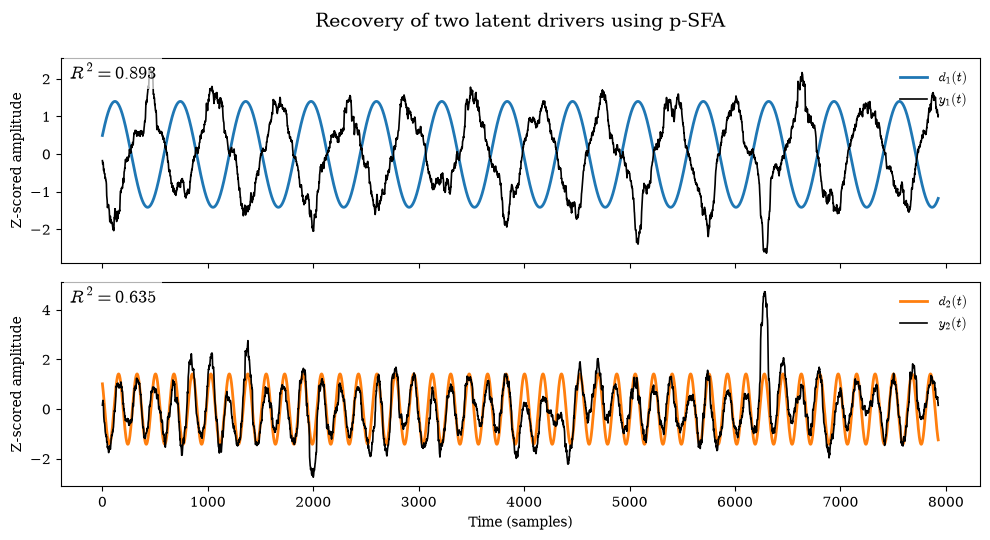

In [17]:
def z(x):
    return (x - np.mean(x)) / np.std(x)

t = np.arange(len(Y))
r2_d1_y1 = corr_mat[0, 0] ** 2
r2_d2_y2 = corr_mat[1, 1] ** 2

fig, axs = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

axs[0].plot(t, z(D_aligned[:, 0]), color="C0", lw=2.0, label=r"$d_1(t)$")
axs[0].plot(t, z(Y[:, 0]), color="k", lw=1.2, label=r"$y_1(t)$")
axs[0].set_ylabel("Z-scored amplitude")
axs[0].set_title("Recovery of two latent drivers using p-SFA\n", fontsize=14)
axs[0].legend(loc="upper right", frameon=False)
axs[0].text(0.01, 0.90, rf"$R^2 = {r2_d1_y1:.3f}$", transform=axs[0].transAxes,
           fontsize=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

axs[1].plot(t, z(D_aligned[:, 1]), color="C1", lw=2.0, label=r"$d_2(t)$")
axs[1].plot(t, z(Y[:, 1]), color="k", lw=1.2, label=r"$y_2(t)$")
axs[1].set_ylabel("Z-scored amplitude")
axs[1].set_xlabel("Time (samples)")
axs[1].legend(loc="upper right", frameon=False)
axs[1].text(0.01, 0.90, rf"$R^2 = {r2_d2_y2:.3f}$", transform=axs[1].transAxes,
           fontsize=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

fig.tight_layout()
save(fig, "supp_s4_two_drivers_correspondence")


saved figures/supp_s4_two_drivers_delta_spectrum.{pdf,png}


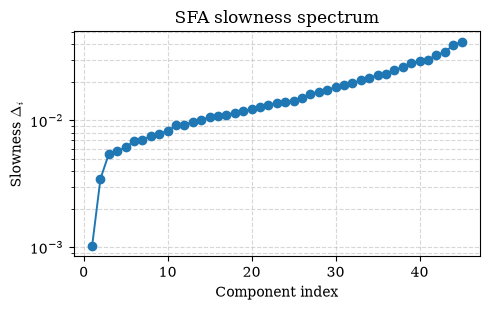

In [18]:
fig2 = plt.figure(figsize=(5, 3.2))
plt.semilogy(np.arange(1, len(delta_vals) + 1), delta_vals, "o-", lw=1.4)
plt.xlabel("Component index")
plt.ylabel(r"Slowness $\Delta_i$")
plt.title("SFA slowness spectrum", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
save(fig2, "supp_s4_two_drivers_delta_spectrum")


## S5 — Fraction of nodes modulated

p-SFA recovery as a function of the size of the modulated subnetwork: only a fraction of nodes participate in the time-varying coupling (the rest have static, driver-independent couplings), and recovery strengthens as that fraction grows.

Ported from the final cells of `extended_VAR_results.ipynb`'s `build_localised_C_base` / `run_localised_modulation_sweep`. That localisation mechanism (restrict modulation to a random k-node subnetwork) already exists in this codebase as `sweeps.build_C`'s `C_frac` parameter, documented there as *"the localisation experiment (Fig. 13 of the manuscript)"* -- so this reuses the existing, already-live `run_sweep` machinery directly rather than porting a second copy of the same mechanism.

In [19]:
from src.sweeps import cfg_with, run_sweep


In [20]:
base_frac = cfg_with(N=10, T=700, tvp_period=200, alpha=1.0, A_0_is_zero=True,
                     node_win=2, edge_win=51, C_include_diagonal=True)

frac_vals = np.linspace(0, 1, num=20)
df_frac = run_sweep("C_frac", frac_vals, seeds=range(10), base=base_frac,
                    features=("edges",))


[sweep] C_frac = 0.0  mean R2_edge = 0.173
[sweep] C_frac = 0.05263157894736842  mean R2_edge = 0.173


[sweep] C_frac = 0.10526315789473684  mean R2_edge = 0.173
[sweep] C_frac = 0.15789473684210525  mean R2_edge = 0.173


[sweep] C_frac = 0.21052631578947367  mean R2_edge = 0.316
[sweep] C_frac = 0.2631578947368421  mean R2_edge = 0.316


[sweep] C_frac = 0.3157894736842105  mean R2_edge = 0.562
[sweep] C_frac = 0.3684210526315789  mean R2_edge = 0.562


[sweep] C_frac = 0.42105263157894735  mean R2_edge = 0.568
[sweep] C_frac = 0.47368421052631576  mean R2_edge = 0.568


...

[sweep] C_frac = 0.7894736842105263  mean R2_edge = 0.764


[sweep] C_frac = 0.8421052631578947  mean R2_edge = 0.732


[sweep] C_frac = 0.894736842105263  mean R2_edge = 0.732


[sweep] C_frac = 0.9473684210526315  mean R2_edge = 0.785


[sweep] C_frac = 1.0  mean R2_edge = 0.785


saved figures/supp_s5_fraction_modulated.{pdf,png}


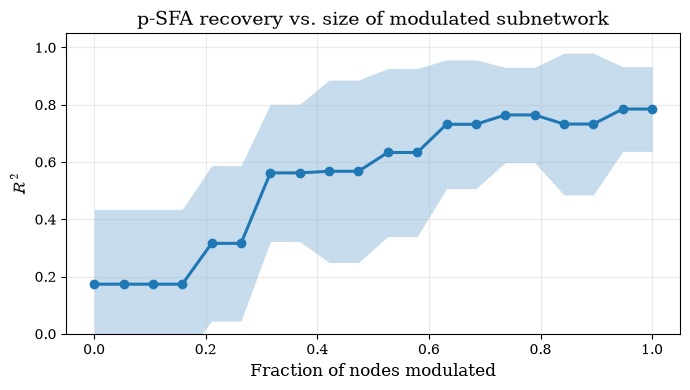

In [21]:
fracs = np.sort(df_frac["C_frac"].unique())
means = np.array([df_frac.loc[df_frac["C_frac"] == f, "R2_edge"].mean() for f in fracs])
stds  = np.array([df_frac.loc[df_frac["C_frac"] == f, "R2_edge"].std()  for f in fracs])

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(fracs, means - stds, means + stds, alpha=0.25, color="C0", linewidth=0)
ax.plot(fracs, means, "-o", color="C0", lw=2.2, ms=6)
ax.set_xlabel("Fraction of nodes modulated", fontsize=12)
ax.set_ylabel(r"$R^2$", fontsize=12)
ax.set_title("p-SFA recovery vs. size of modulated subnetwork", fontsize=14)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
fig.tight_layout()
save(fig, "supp_s5_fraction_modulated")
